In [35]:
pkgs <- c(
  "tidymodels",
  'glmnet',
  "rstanarm", 
  "reticulate",
  'yardstick'
)
instalar <- pkgs[!pkgs %in% installed.packages()[, "Package"]]

if (length(instalar) > 0) {
  install.packages(instalar)
}
library(caret)
library(tidyverse)
library("tidymodels")
library('janitor')
library('ggcorrplot')
library(workflowsets)
library(rstanarm)
library(glmnet)
library(reticulate)
library(ggplot2)
library(patchwork)
library(dplyr)

py_config()
reticulate::py_install(c("pandas", "tabulate", "ipython"))

set.seed(42)

Carregando pacotes exigidos: lattice


Anexando pacote: 'caret'


Os seguintes objetos são mascarados por 'package:rstanarm':

    compare_models, R2


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ purrr::lift()   masks caret::lift()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.5.0 ──

✔ broom        1.0.12     ✔ rsample      1.3.2 
✔ dials        1.4.3      ✔ tailor       0.1.0 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.5.0      ✔ workflo

Error in python_config_impl(python) : 
  Error 103 occurred running C:/Users/T-GAMER/OneDrive/Documentos/.virtualenvs/r-reticulate/Scripts/python.exe: 


python:         C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Scripts/python.exe
libpython:      C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/python/cpython-3.12.13-windows-x86_64-none/python312.dll
pythonhome:     C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG
virtualenv:     C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Scripts/activate_this.py
version:        3.12.13 (main, Apr 14 2026, 14:31:26) [MSC v.1944 64 bit (AMD64)]
Architecture:   64bit
numpy:          C:/Users/T-GAMER/AppData/Local/R/cache/R/reticulate/uv/cache/archive-v0/Z7yLGySVAB_TMH-wsihzG/Lib/site-packages/numpy
numpy_version:  2.5.1

NOTE: Python version was forced by py_require()

Warning message in reticulate::py_install(c("pandas", "tabulate", "ipython")):
"An ephemeral virtual environment managed by 'reticulate' is currently in use.
To add more packages to your current session, call `py_require()` instead
of `py_install()`. Running:
  `py_require(c("pandas", "tabulate", "ipython"))`"


In [36]:
loan <- read_csv("data/Loan/loan_approval_dataset.csv") |>
  clean_names()

#https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
default <- read_csv("data/default/UCI_Credit_Card.csv")

Rows: 4269 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): education, self_employed, loan_status
dbl (10): loan_id, no_of_dependents, income_annum, loan_amount, loan_term, c...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30000 Columns: 25
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (25): ID, LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, PAY_0, PAY_2, PAY_3,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [37]:
loan <- loan %>%
  rename(
    num_dependentes      = no_of_dependents,
    escolaridade         = education,
    autonomo             = self_employed,
    renda_anual          = income_annum,
    valor_emprestimo     = loan_amount,
    prazo_anos           = loan_term,
    score_credito        = cibil_score,
    ativos_residenciais  = residential_assets_value,
    ativos_comerciais    = commercial_assets_value,
    ativos_luxo          = luxury_assets_value,
    ativos_bancarios     = bank_asset_value,
    status    = loan_status
)

loan <- loan %>%
  dplyr::select(-loan_id)

loan$status <- ifelse(
  loan$status %in% c("Approved", 1, "1"),
  1, 0
)
loan$status <- as.factor(loan$status)

In [38]:
default <- default %>%
  rename(
    id_cliente = ID,
    limite_credito = LIMIT_BAL,
    sexo = SEX,
    escolaridade = EDUCATION,
    estado_civil = MARRIAGE,
    idade = AGE,
    atraso_pagto_0 = PAY_0,
    atraso_pagto_2 = PAY_2,
    atraso_pagto_3 = PAY_3,
    atraso_pagto_4 = PAY_4,
    atraso_pagto_5 = PAY_5,
    atraso_pagto_6 = PAY_6,
    fatura_valor_1 = BILL_AMT1,
    fatura_valor_2 = BILL_AMT2,
    fatura_valor_3 = BILL_AMT3,
    fatura_valor_4 = BILL_AMT4,
    fatura_valor_5 = BILL_AMT5,
    fatura_valor_6 = BILL_AMT6,
    pagto_valor_1 = PAY_AMT1,
    pagto_valor_2 = PAY_AMT2,
    pagto_valor_3 = PAY_AMT3,
    pagto_valor_4 = PAY_AMT4,
    pagto_valor_5 = PAY_AMT5,
    pagto_valor_6 = PAY_AMT6,
    PD30 = default.payment.next.month
)
default <- default %>%
  dplyr::select(-id_cliente)

default$PD30 <- as.factor(default$PD30)

In [39]:
split_loan <- initial_split(
  loan,
  prop   = 0.75,
  strata = status
)

train_data_loan <- training(split_loan)
test_data_loan  <- testing(split_loan)

split_default <- initial_split(
  default,
  prop   = 0.75,
  strata = PD30
)

train_data_default <- training(split_default)
test_data_default  <- testing(split_default)

------------------------------------------------------
para o frequentista
- Modelo geral (tudo) OK
- Modelo apenas com score Ok
- Modelo sem score ok
- Modelo com remoção das feats correlacionadas ok
- Modelo com PCA
- Modelo com regularização para selecionar feats (glmnet) ok

In [40]:
log_glm <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")
#lasso
log_l1 <- logistic_reg(
  penalty = tune(),
  mixture = 1
) |>
  set_engine("glmnet") |>
  set_mode("classification")

In [41]:
folds <- vfold_cv(train_data_loan, v = 5, strata = status)
grid <- grid_regular(
  penalty(range = c(-5, 0)),  # 1e-4 até 1
  levels = 20
)

metrics <- metric_set(
  accuracy,
  roc_auc,
  f_meas
)

In [42]:
#
rec_all <- recipe(status ~ ., data = train_data_loan) %>%
  step_dummy(all_nominal_predictors())


rec_l1 <- recipe(status ~ ., data = train_data_loan) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

rec_score_only <- recipe(
  status ~ score_credito,
  data = train_data_loan
)%>%
  step_dummy(all_nominal_predictors())
rec_no_score <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_rm(score_credito)

rec_no_corr <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_corr(all_numeric_predictors(), threshold = 0.75)

rec_pca <- recipe(
  status ~ .,
  data = train_data_loan
) %>%
  step_dummy(all_nominal_predictors())%>%
  step_normalize(all_numeric_predictors()) %>% 
  step_pca(
    all_numeric_predictors(),
    threshold = 0.95
  )

In [43]:
wf_logit <- workflow_set(
  preproc = list(
    all_features = rec_all,
    score_only   = rec_score_only,
    no_score     = rec_no_score,
    no_corr      = rec_no_corr,
    pca          = rec_pca
  ),
  models = list(
    logit = log_glm
  )
)

wf_l1 <- workflow() %>%
  add_recipe(rec_l1) %>%
  add_model(log_l1)

tuned_l1 <- tune_grid(
  wf_l1,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

→ A | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Precision is undefined in this case, and `NA` will be returned.
               Note that 242 true event(s) actually occurred for the problematic event level,
               0

There were issues with some computations   A: x2

There were issues with some computations   A: x8

→ B | warning: While computing binary `precision()`, no predicted events were detected (i.e.
               `true_positive + false_positive = 0`).
               Precision is undefined in this case, and `NA` will be returned.
               Note that 241 true event(s) actually occurred for the problematic event level,
               0

There were issues with some computations   A: x8
There were issues with some computations   A: x8   B: x2





Durante o processo de validação cruzada, observou-se que, para alguns valores elevados do parâmetro de regularização no modelo L1, o classificador passou a prever exclusivamente a classe majoritária. Nesses casos, métricas como precision tornam-se indefinidas, uma vez que não há predições positivas. Esse comportamento é esperado em cenários de forte regularização combinados com desbalanceamento de classes, e reforça a inadequação de métricas baseadas apenas em acertos globais ou em predições positivas para a seleção do modelo. Por essa razão, a comparação e seleção dos modelos foi baseada prioritariamente em métricas robustas ao desbalanceamento, como ROC-AUC, balanced accuracy e MCC.

In [44]:
best_l1 <- select_best(tuned_l1, metric = "roc_auc")
final_l1 <- finalize_workflow(wf_l1, best_l1)
fit_l1 <- fit(final_l1, train_data_loan)

In [45]:
library(broom)

coef_table <- extract_fit_engine(fit_l1) |>
  coef(s = best_l1$penalty)
  coef_table

12 x 1 sparse Matrix of class "dgCMatrix"
                          s=0.001274275
(Intercept)                1.6349690770
num_dependentes           -0.0244620575
renda_anual               -0.9185374316
valor_emprestimo           0.9357611025
prazo_anos                -0.7531826435
score_credito              3.9285272022
ativos_residenciais        0.0304063656
ativos_comerciais          0.0076553420
ativos_luxo                0.0002451705
ativos_bancarios           0.0003551518
escolaridade_Not.Graduate -0.0586119770
autonomo_Yes               0.0217906829

In [79]:
fits <- wf_logit %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data_loan)
    )
  )

In [80]:
library(dplyr)
library(purrr)
library(yardstick)

preds <- fits %>%
  mutate(
    preds = purrr::map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data_loan, type = "prob")

        tibble(
          truth = test_data_loan$status,
          class = predict(.x, test_data_loan, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, preds)

In [81]:
preds <-preds %>%
  tidyr::unnest(preds)

In [82]:
library(tibble)
library(yardstick)

#old version

calc_metrics_from_fit <- function(fit, test_data, truth_col = status) {

  # predições
  prob_tbl  <- predict(fit, test_data, type = "prob")
  class_tbl <- predict(fit, test_data, type = "class")

  truth <- test_data[[deparse(substitute(truth_col))]]
  class <- class_tbl$.pred_class
  prob  <- prob_tbl$.pred_1

  tibble(
    accuracy     = accuracy_vec(truth, class),
    bal_accuracy = bal_accuracy_vec(truth, class),

    roc_auc  = roc_auc_vec(truth, prob, event_level = "second"),
    log_loss = mn_log_loss_vec(truth, prob),

    sens = sens_vec(truth, class),
    spec = spec_vec(truth, class),

    precision = precision_vec(truth, class),
    npv       = npv_vec(truth, class),

    f1 = f_meas_vec(truth, class),
    f2 = f_meas_vec(truth, class, beta = 2),

    kap = kap_vec(truth, class),
    mcc = mcc_vec(truth, class),

    gmean = sqrt(
      sens_vec(truth, class) * spec_vec(truth, class)
    )
  )
}

In [83]:
names(fits)

[1] "wflow_id" "info"     "option"   "result"   "fit"

In [85]:
metrics_wf <- fits %>%
  mutate(
    metrics = purrr::map(
      fit,
      ~ calc_metrics_from_fit(
        fit = .x,
        test_data = test_data_loan,
        truth_col = status
      )
    )
  ) %>%
  select(wflow_id, metrics) %>%
  tidyr::unnest(metrics)


metrics_l1 <- calc_metrics_from_fit(
  fit = fit_l1,
  test_data = test_data_loan,
  truth_col = status
) %>%
  mutate(wflow_id = "l1_logit")

metrics_table_final <- bind_rows(
  metrics_wf,
  metrics_l1
)
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904
l1_logit,0.9250936,0.9208592,0.9760043,3.6257228,0.90346535,0.9382530,0.8990148,0.9410876,0.90123457,0.90257171,0.84090334,0.84090999,0.9206949


In [19]:
extract_model_summary <- function(wf_fit) {
  model_fit <- workflows::extract_fit_parsnip(wf_fit)

  if (inherits(model_fit$fit, "glm")) {
    return(summary(model_fit$fit))
  }

  if (inherits(model_fit$fit, "lognet")) {
    return(model_fit$fit)
  }

  NULL
}

In [22]:
model_summaries <- fits %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -1.073e+01  4.785e-01 -22.422  < 2e-16 ***
num_dependentes           -2.446e-02  3.988e-02  -0.613    0.540    
renda_anual               -5.785e-07  1.028e-07  -5.629 1.82e-08 ***
valor_emprestimo           1.369e-07  2.055e-08   6.662 2.71e-11 ***
prazo_anos                -1.432e-01  1.287e-02 -11.120  < 2e-16 ***
score_credito              2.366e-02  9.076e-04  26.068  < 2e-16 ***
ativos_residenciais        1.262e-08  1.330e-08   0.949    0.343    
ativos_comerciais          1.307e-08  1.962e-08   0.666    0.505    
ativos_luxo                2.658e-08  1.989e-08   1.336    0.181    
ativos_bancarios           3.961e-08  3.804e-08   1.041    0.298    
escolaridade_Not.Graduate -1.679e-01  1.347e-01  -1.247    0.212    
autonomo_Yes               6.747e-02  1.338e-01   0

In [23]:
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904
l1_logit,0.9250936,0.9208592,0.9760043,3.6257228,0.90346535,0.9382530,0.8990148,0.9410876,0.90123457,0.90257171,0.84090334,0.84090999,0.9206949


In [24]:
fits_vif <- fits %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_corr_logit",
      "no_score_logit",
      "feat_select_logit"
    )
  )

#apenas os modelos sem PCA...

In [25]:
library(car)

calc_vif <- function(wf_fit) {
  wf_fit %>%
    workflows::extract_fit_parsnip() %>%
    pluck("fit") %>%      # objeto glm
    car::vif()
}

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )

Carregando pacotes exigidos: carData

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4


Anexando pacote: 'car'


O seguinte objeto é mascarado por 'package:rstanarm':

    logit


O seguinte objeto é mascarado por 'package:dplyr':

    recode


O seguinte objeto é mascarado por 'package:purrr':

    some




In [26]:
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

In [27]:
vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )
vif_summary

wflow_id,max_vif,mean_vif
<chr>,<dbl>,<dbl>
all_features_logit,18.667257,4.225453
no_corr_logit,1.586206,1.226418
no_score_logit,17.106545,4.227158


In [28]:
library(dplyr)

model_summary <- metrics_table_final %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.9269663,0.9228498,0.9762018,3.8004860,0.90594059,0.9397590,0.9014778,0.9425982,0.90370370,0.90504451,0.84488075,0.84488744,0.9226949,18.667257,4.225453
score_only_logit,0.9213483,0.9173625,0.9651769,3.2187954,0.90099010,0.9337349,0.8921569,0.9393939,0.89655172,0.89920949,0.83311010,0.83313641,0.9172164,NA,NA
no_score_logit,0.6207865,0.5065162,0.6161838,0.8217493,0.03712871,0.9759036,0.4838710,0.6248795,0.06896552,0.04553734,0.01590783,0.03764666,0.1903524,17.106545,4.227158
no_corr_logit,0.9307116,0.9278003,0.9736334,3.6179562,0.91584158,0.9397590,0.9024390,0.9483283,0.90909091,0.91312932,0.85312003,0.85318053,0.9277232,1.586206,1.226418
pca_logit,0.9279026,0.9255413,0.9736148,3.6180796,0.91584158,0.9352410,0.8958838,0.9480916,0.90575275,0.91177920,0.84738667,0.84752151,0.9254904,NA,NA
l1_logit,0.9250936,0.9208592,0.9760043,3.6257228,0.90346535,0.9382530,0.8990148,0.9410876,0.90123457,0.90257171,0.84090334,0.84090999,0.9206949,NA,NA


A Tabela X apresenta o desempenho dos diferentes modelos de regressão logística ajustados para o problema de concessão de empréstimos, considerando variações na especificação do conjunto de preditores e técnicas de redução de dimensionalidade e regularização. De forma geral, observa-se que os modelos que incorporam informações financeiras completas ou o credit score apresentam desempenho substancialmente superior ao modelo sem essa variável, evidenciando o papel central do score de crédito na discriminação entre solicitações aprovadas e recusadas.

O modelo com todas as variáveis (all_features_logit) apresentou elevado poder discriminatório, com AUC de 0,976 e acurácia balanceada de aproximadamente 0,923. No entanto, essa especificação exibiu indícios relevantes de multicolinearidade, refletidos em valores elevados de VIF máximo (18,67), especialmente entre variáveis relacionadas a renda e patrimônio. Em contraste, o modelo sem variáveis altamente correlacionadas (no_corr_logit) manteve desempenho preditivo comparável — com a maior acurácia (0,931) e g-mean (0,928) entre os modelos testados — ao mesmo tempo em que reduziu substancialmente a multicolinearidade (VIF máximo inferior a 2), configurando um bom compromisso entre ajuste estatístico e estabilidade dos coeficientes.

O modelo baseado em PCA apresentou desempenho muito próximo ao do modelo sem correlação, com AUC de 0,974 e acurácia balanceada de 0,926. Apesar disso, a transformação dos preditores em componentes principais reduz a interpretabilidade direta dos coeficientes, o que limita sua atratividade em um contexto aplicado de crédito, no qual a transparência do modelo é um requisito relevante.

O modelo regularizado com L1 (Lasso) também demonstrou desempenho robusto (AUC = 0,976), comparável ao modelo completo, ao mesmo tempo em que promoveu seleção automática de variáveis. Ainda assim, os ganhos preditivos em relação às abordagens mais simples foram marginais, sugerindo que a penalização atua principalmente como mecanismo de parcimônia, e não como fator decisivo de melhoria de desempenho.

Por fim, o modelo apenas com score de crédito (score_only_logit) apresentou desempenho surpreendentemente competitivo, com AUC de 0,965 e acurácia balanceada de 0,917, apesar de sua extrema simplicidade. A pequena perda de desempenho em relação aos modelos mais complexos indica que o score sintetiza de forma eficaz grande parte da informação relevante para a decisão de crédito. Em contraste, o modelo sem score apresentou desempenho significativamente inferior, com AUC próxima a 0,62 e sensibilidade extremamente baixa, reforçando a dependência do processo decisório dessa variável.

Em conjunto, esses resultados indicam que, embora modelos mais complexos ofereçam ganhos marginais de desempenho, abordagens mais parcimoniosas — em especial o modelo baseado exclusivamente no score de crédito ou o modelo sem variáveis altamente correlacionadas — representam alternativas atraentes, equilibrando capacidade preditiva, estabilidade estatística e interpretabilidade.

Considerando conjuntamente os resultados de desempenho preditivo, as propriedades estatísticas dos modelos e os objetivos do estudo, optou-se por adotar o modelo de regressão logística baseado exclusivamente no score de crédito como especificação final. Embora modelos mais complexos tenham apresentado métricas ligeiramente superiores — em particular AUC e acurácia balanceada —, os ganhos observados foram marginais quando comparados ao aumento substancial de complexidade, à presença de multicolinearidade e à perda de interpretabilidade. O modelo com score único apresentou desempenho robusto e estável, com elevada capacidade discriminatória, mantendo simplicidade estrutural, coeficientes facilmente interpretáveis e menor risco de sobreajuste. Essa escolha está alinhada com o princípio da parcimônia e com práticas consolidadas em modelagem de risco de crédito, nas quais modelos mais simples, transparentes e estatisticamente bem comportados são preferidos quando oferecem desempenho comparável. Ressalta-se que todos os modelos candidatos foram previamente avaliados quanto ao ajuste, consistência estatística e diagnóstico de resíduos, e a seleção final foi realizada de forma informada, priorizando o equilíbrio entre desempenho, robustez e aplicabilidade prática.

In [29]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

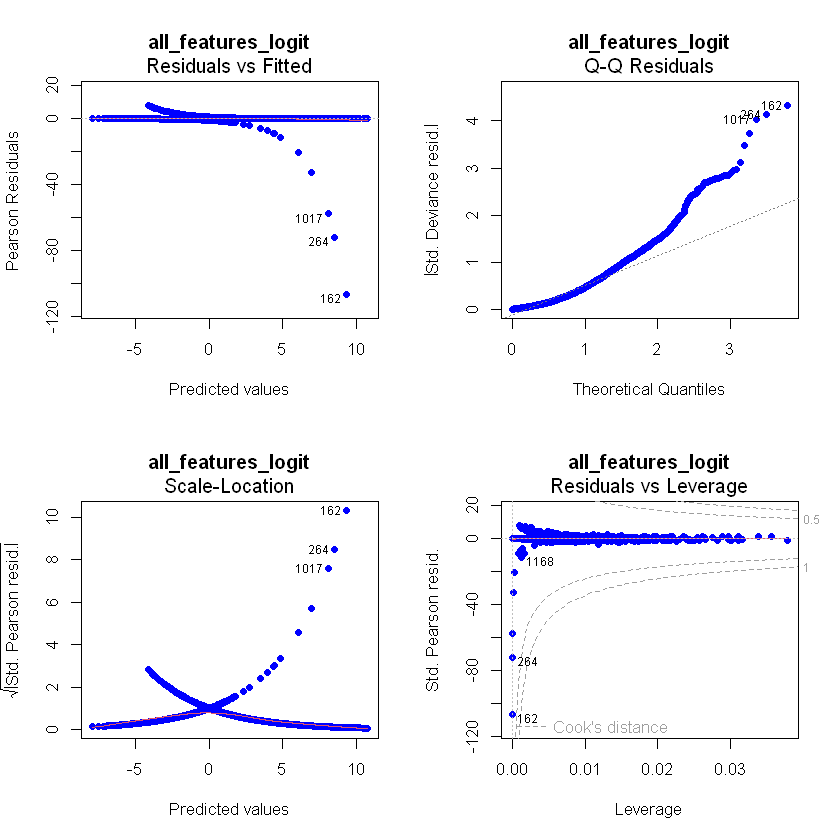

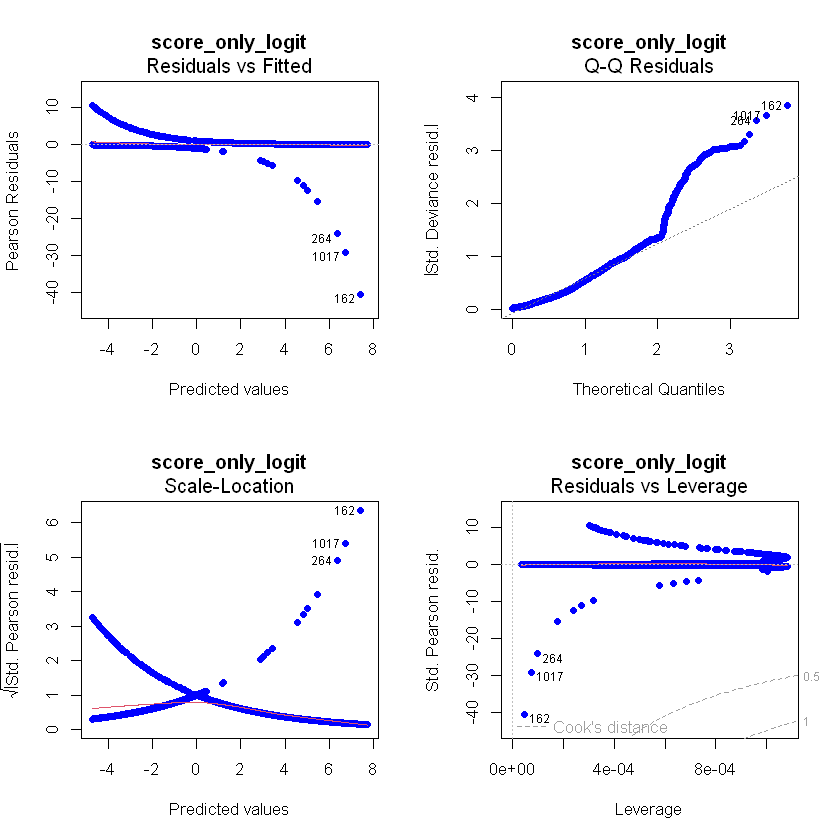

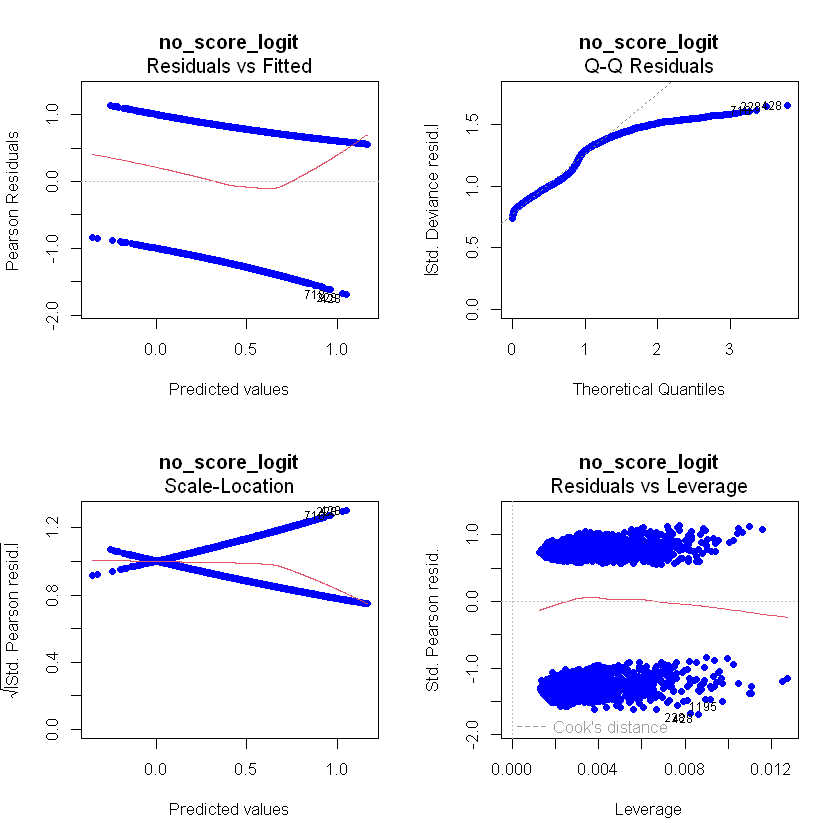

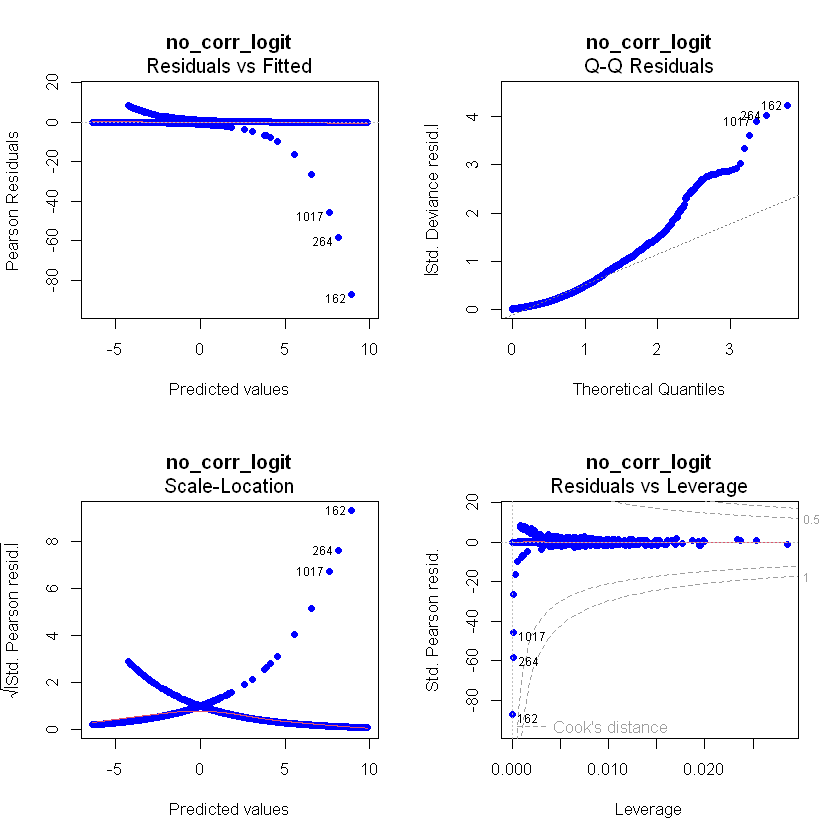

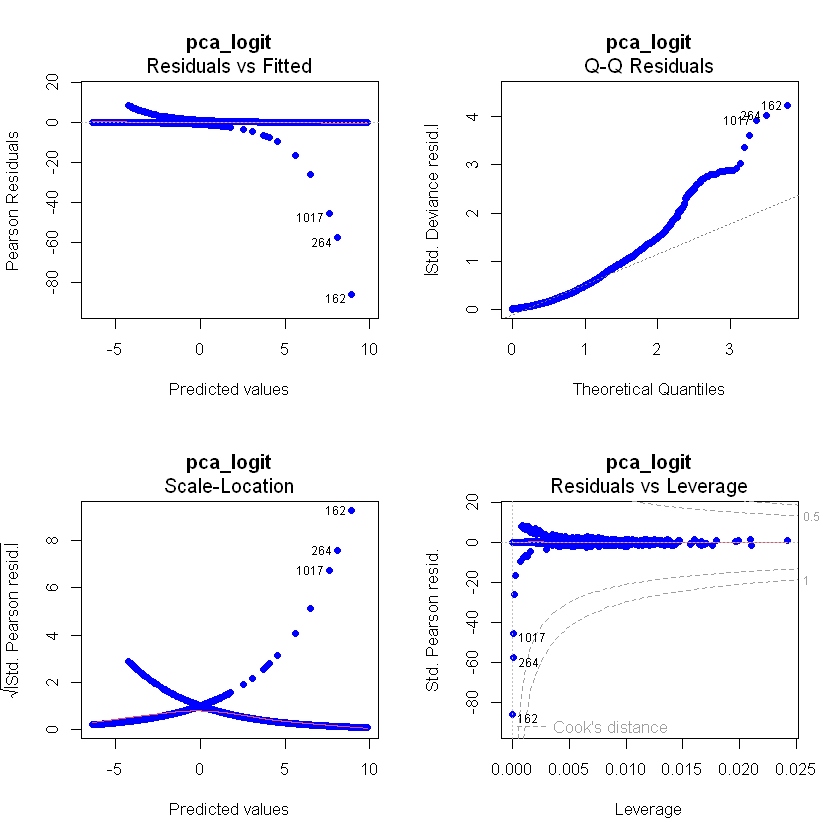

In [31]:
purrr::walk2(
  fits$fit,
  fits$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

[1] 486

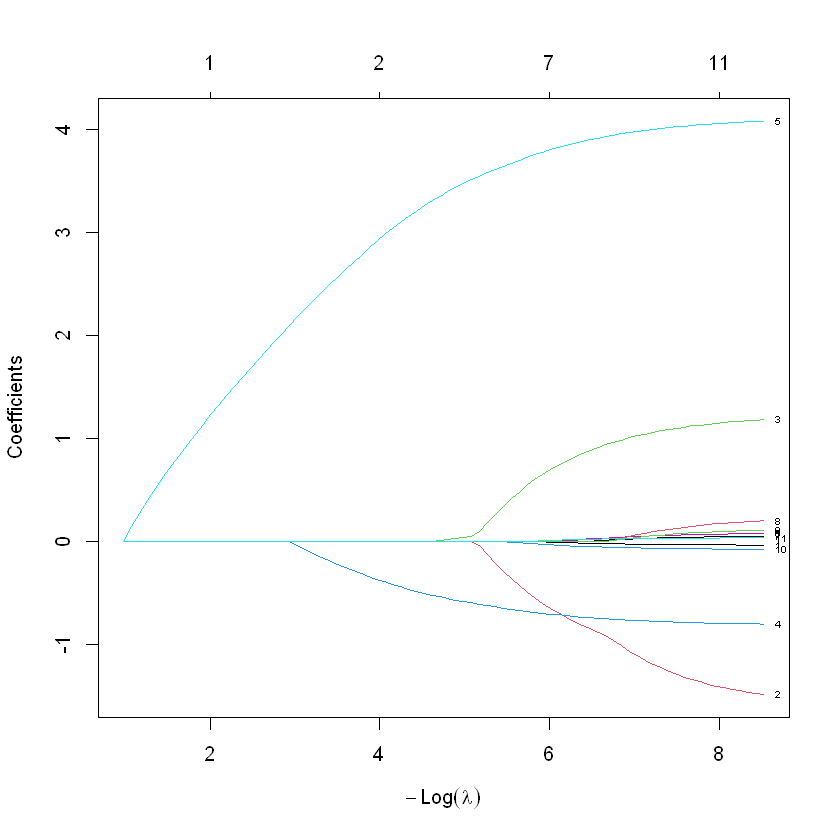

In [32]:
glmnet_fit <- fit_l1 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l1 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l1 != 0)

DEFAULT TIME

In [33]:
log_glm <- logistic_reg() |>
  set_engine("glm") |>
  set_mode("classification")
#lasso
log_l1 <- logistic_reg(
  penalty = tune(),
  mixture = 1
) |>
  set_engine("glmnet") |>
  set_mode("classification")

folds <- vfold_cv(train_data_default, v = 5, strata = PD30)
grid <- grid_regular(
  penalty(range = c(-4, 0)),  # 1e-4 até 1
  levels = 20
)

In [34]:
#modelo geral
rec_all <- recipe(PD30 ~ ., data = train_data_default) %>%
  step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())

rec_l1 <- recipe(
  PD30 ~ .,
  data = train_data_default
) %>% step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors())
#rodar L1



# Removendo alta correlação
rec_corr <- recipe(
  PD30 ~ .,
  data = train_data_default
) %>% step_dummy(all_nominal_predictors()) %>%
  step_corr(all_numeric_predictors(), threshold = 0.7)


#com pca
rec_pca <- recipe(
  PD30 ~ .,
  data = train_data_default
) %>% step_dummy(all_nominal_predictors()) %>%
  step_normalize(all_numeric_predictors()) %>%
  step_pca(all_numeric_predictors(), threshold = 0.95)

In [35]:
wf_logit_default <- workflow_set(
  preproc = list(
    all_features = rec_all,
    no_corr      = rec_corr,
    pca          = rec_pca
  ),
  models = list(
    logit = log_glm
  )
)
wf_l1 <- workflow() %>%
  add_recipe(rec_l1) %>%
  add_model(log_l1)

tuned_l1 <- tune_grid(
  wf_l1,
  resamples = folds,
  grid = grid,
  metrics = metrics
)

In [36]:
best_l1 <- select_best(tuned_l1, metric = "roc_auc")
final_l1 <- finalize_workflow(wf_l1, best_l1)
fit_l1 <- fit(final_l1, train_data_default)

In [37]:
library(broom)

coef_table <- extract_fit_engine(fit_l1) |>
  coef(s = best_l1$penalty)
  coef_table

24 x 1 sparse Matrix of class "dgCMatrix"
               s=0.0001623777
(Intercept)      -1.466639813
limite_credito   -0.094661311
sexo             -0.035004786
escolaridade     -0.072950332
estado_civil     -0.089415722
idade             0.055133092
atraso_pagto_0    0.648918405
atraso_pagto_2    0.126711935
atraso_pagto_3    0.095425647
atraso_pagto_4    0.006374048
atraso_pagto_5    0.063915465
atraso_pagto_6   -0.001422033
fatura_valor_1   -0.328195526
fatura_valor_2    0.089114652
fatura_valor_3    0.072774015
fatura_valor_4    .          
fatura_valor_5    0.061297241
fatura_valor_6    .          
pagto_valor_1    -0.203277601
pagto_valor_2    -0.169973920
pagto_valor_3    -0.102813317
pagto_valor_4    -0.028684425
pagto_valor_5    -0.031330571
pagto_valor_6    -0.044343025

In [39]:
fits <- wf_logit_default %>%
  mutate(
    fit = purrr::map(
      info,
      ~ fit(.x$workflow[[1]], data = train_data_default)
    )
  )

In [41]:
library(dplyr)
library(purrr)
library(yardstick)

preds <- fits %>%
  mutate(
    preds = purrr::map(
      fit,
      ~{
        prob_tbl <- predict(.x, test_data_default, type = "prob")

        tibble(
          truth = test_data_default$PD30,
          class = predict(.x, test_data_default, type = "class")$.pred_class,
          prob  = prob_tbl$.pred_1
        )
      }
    )
  ) %>%
  select(wflow_id, preds)

preds <- preds %>%
  tidyr::unnest(preds)

In [43]:
metrics_wf <- fits %>%
  mutate(
    metrics = purrr::map(
      fit,
      ~ calc_metrics_from_fit(
        fit = .x,
        test_data = test_data_default,
        truth_col = PD30
      )
    )
  ) %>%
  select(wflow_id, metrics) %>%
  tidyr::unnest(metrics)

metrics_l1 <- calc_metrics_from_fit(
  fit = fit_l1,
  test_data = test_data_default,
  truth_col = PD30
) %>%
  mutate(wflow_id = "l1_logit")

metrics_table_final <- bind_rows(
  metrics_wf,
  metrics_l1
)
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,1.561558,0.9681561,0.2423146,0.8181424,0.6836735,0.8868502,0.9339080,0.2737316,0.3249886,0.4843536
no_corr_logit,0.8074667,0.6051498,0.7112449,1.554452,0.9679849,0.2423146,0.8181160,0.6825127,0.8867629,0.9337737,0.2734322,0.3244719,0.4843108
pca_logit,0.8064000,0.6031703,0.7099724,1.552201,0.9676425,0.2386980,0.8173536,0.6769231,0.8861712,0.9333201,0.2685861,0.3193577,0.4805979
l1_logit,0.8074667,0.6042867,0.7132359,1.556983,0.9686697,0.2399036,0.8177482,0.6850258,0.8868339,0.9341875,0.2717978,0.3238290,0.4820657


In [44]:
model_summaries <- fits %>%
  mutate(
    summary = purrr::map(fit, extract_model_summary)
  ) %>%
  select(wflow_id, summary)
  
for (i in seq_len(nrow(model_summaries))) {
  cat("\n==============================\n")
  cat("Modelo:", model_summaries$wflow_id[i], "\n")
  cat("==============================\n\n")
  print(model_summaries$summary[[i]])
}


Modelo: all_features_logit 


Call:
stats::glm(formula = ..y ~ ., family = stats::binomial, data = data)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.470133   0.019201 -76.564  < 2e-16 ***
limite_credito -0.094839   0.023706  -4.001 6.32e-05 ***
sexo           -0.036114   0.017422  -2.073 0.038188 *  
escolaridade   -0.075327   0.019196  -3.924 8.71e-05 ***
estado_civil   -0.090806   0.019166  -4.738 2.16e-06 ***
idade           0.056285   0.019068   2.952 0.003159 ** 
atraso_pagto_0  0.648442   0.023033  28.153  < 2e-16 ***
atraso_pagto_2  0.128389   0.027854   4.609 4.04e-06 ***
atraso_pagto_3  0.093754   0.031167   3.008 0.002629 ** 
atraso_pagto_4  0.006974   0.033770   0.207 0.836393    
atraso_pagto_5  0.069798   0.035317   1.976 0.048116 *  
atraso_pagto_6 -0.009761   0.029763  -0.328 0.742944    
fatura_valor_1 -0.428512   0.098006  -4.372 1.23e-05 ***
fatura_valor_2  0.189962   0.124973   1.520 0.128504    
fatura_valor_3  0.106235

In [45]:
metrics_table_final

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,1.561558,0.9681561,0.2423146,0.8181424,0.6836735,0.8868502,0.9339080,0.2737316,0.3249886,0.4843536
no_corr_logit,0.8074667,0.6051498,0.7112449,1.554452,0.9679849,0.2423146,0.8181160,0.6825127,0.8867629,0.9337737,0.2734322,0.3244719,0.4843108
pca_logit,0.8064000,0.6031703,0.7099724,1.552201,0.9676425,0.2386980,0.8173536,0.6769231,0.8861712,0.9333201,0.2685861,0.3193577,0.4805979
l1_logit,0.8074667,0.6042867,0.7132359,1.556983,0.9686697,0.2399036,0.8177482,0.6850258,0.8868339,0.9341875,0.2717978,0.3238290,0.4820657


In [ ]:
fits_vif <- fits %>%
  dplyr::filter(
    wflow_id %in% c(
      "all_features_logit",
      "no_corr_logit"
    )
  )

vif_results <- fits_vif %>%
  mutate(
    vif = purrr::map(fit, calc_vif)
  )
vif_tidy <- vif_results %>%
  select(wflow_id, vif) %>%
  tidyr::unnest_longer(vif, values_to = "vif") %>%
  rename(variable = vif_id)

vif_summary <- vif_tidy %>%
  group_by(wflow_id) %>%
  summarise(
    max_vif = max(vif),
    mean_vif = mean(vif)
  )

In [48]:
library(dplyr)

model_summary <- metrics_table_final %>%
  left_join(
    vif_summary %>%
      group_by(wflow_id) %>%
      summarise(
        max_vif = max(max_vif, na.rm = TRUE),
        mean_vif = mean(mean_vif, na.rm = TRUE)
      ),
    by = "wflow_id"
  )
model_summary

wflow_id,accuracy,bal_accuracy,roc_auc,log_loss,sens,spec,precision,npv,f1,f2,kap,mcc,gmean,max_vif,mean_vif
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
all_features_logit,0.8076000,0.6052354,0.7136508,1.561558,0.9681561,0.2423146,0.8181424,0.6836735,0.8868502,0.9339080,0.2737316,0.3249886,0.4843536,18.667257,4.225453
no_corr_logit,0.8074667,0.6051498,0.7112449,1.554452,0.9679849,0.2423146,0.8181160,0.6825127,0.8867629,0.9337737,0.2734322,0.3244719,0.4843108,1.586206,1.226418
pca_logit,0.8064000,0.6031703,0.7099724,1.552201,0.9676425,0.2386980,0.8173536,0.6769231,0.8861712,0.9333201,0.2685861,0.3193577,0.4805979,NA,NA
l1_logit,0.8074667,0.6042867,0.7132359,1.556983,0.9686697,0.2399036,0.8177482,0.6850258,0.8868339,0.9341875,0.2717978,0.3238290,0.4820657,NA,NA


Os resultados da segunda configuração de modelos indicam um cenário distinto, no qual as diferenças entre as abordagens tornam-se ainda mais sutis em termos de desempenho global. Observa-se que todos os modelos apresentam valores muito próximos de acurácia (~0,806–0,808) e AUC (~0,709–0,714), sugerindo que, sob essa formulação do problema, a capacidade discriminativa dos modelos é essencialmente equivalente.

Apesar disso, nota-se um padrão consistente de alta sensibilidade (recall da classe positiva) em todos os modelos (≈0,967–0,969), acompanhado de baixa especificidade (~0,24), indicando uma forte tendência dos modelos em classificar observações como positivas. Esse comportamento resulta em um trade-off claro: os modelos conseguem identificar quase todos os casos positivos, mas à custa de um número elevado de falsos positivos, o que se reflete na baixa balanced accuracy (~0,60) e em métricas de equilíbrio como MCC e Kappa relativamente reduzidas.

Entre as abordagens, o modelo com regularização L1 (l1_logit) e o modelo sem variáveis altamente correlacionadas (no_corr_logit) apresentam leve vantagem em termos de estabilidade geral e equilíbrio entre métricas, embora as diferenças sejam marginais. O modelo com PCA não apresenta ganhos relevantes de desempenho, reforçando que a redução dimensional, neste caso, não melhora a separabilidade do problema.

Comparando objetivamente

Você tem basicamente isso:

l1_logit
desempenho: praticamente igual aos outros
vantagem: faz seleção automática de variáveis
efeito: reduz complexidade e ajuda com colinearidade de forma “implícita”
interpretabilidade: ainda boa (coeficientes existem e são diretos)
no_corr_logit
desempenho: também praticamente igual
vantagem: remove correlação “na mão” (pré-processamento explícito)
efeito: mais controle metodológico, mas depende de decisão arbitrária de threshold
interpretabilidade: boa, e mais “limpa” do ponto de vista de diagnóstico

Optou-se pelo modelo com regularização L1 como especificação final por se tratar de uma abordagem mais consistente do ponto de vista metodológico e menos dependente de decisões arbitrárias no pré-processamento. Enquanto a remoção manual de variáveis altamente correlacionadas requer a definição de um limiar ad hoc (por exemplo, 0,7 ou 0,8), o que pode afetar diretamente a estabilidade e a reprodutibilidade da análise, a penalização L1 incorpora esse controle de forma intrínseca ao processo de estimação.

Nesse contexto, o L1 atua simultaneamente como mecanismo de regularização e seleção de variáveis, reduzindo automaticamente coeficientes redundantes em grupos de preditores correlacionados e promovendo maior parcimônia do modelo sem necessidade de intervenção manual na estrutura dos dados. Além disso, os resultados empíricos indicam que o desempenho preditivo do modelo L1 é equivalente aos demais modelos testados, não havendo perda significativa em métricas como ROC-AUC, balanced accuracy e F1-score.

Assim, a escolha pelo L1 é justificada pela combinação de três fatores principais: (i) eliminação da arbitrariedade na seleção de variáveis, (ii) controle implícito da multicolinearidade dentro do próprio processo de estimação e (iii) manutenção do desempenho preditivo com maior robustez e reprodutibilidade do pipeline.

In [49]:
get_model <- function(wf_fit) {
  workflows::extract_fit_parsnip(wf_fit)$fit
}

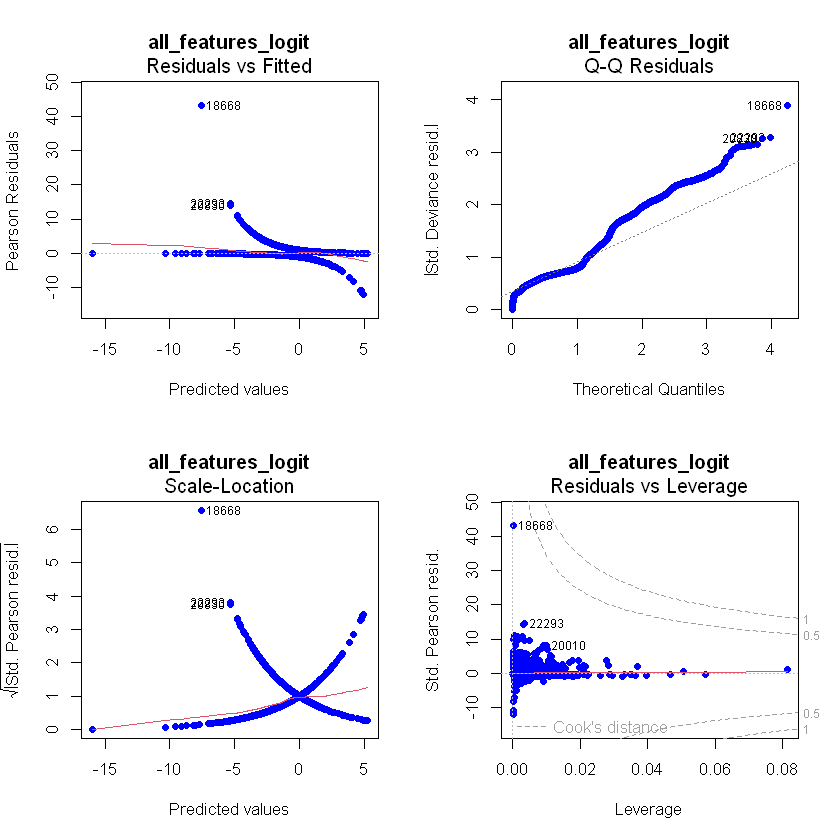

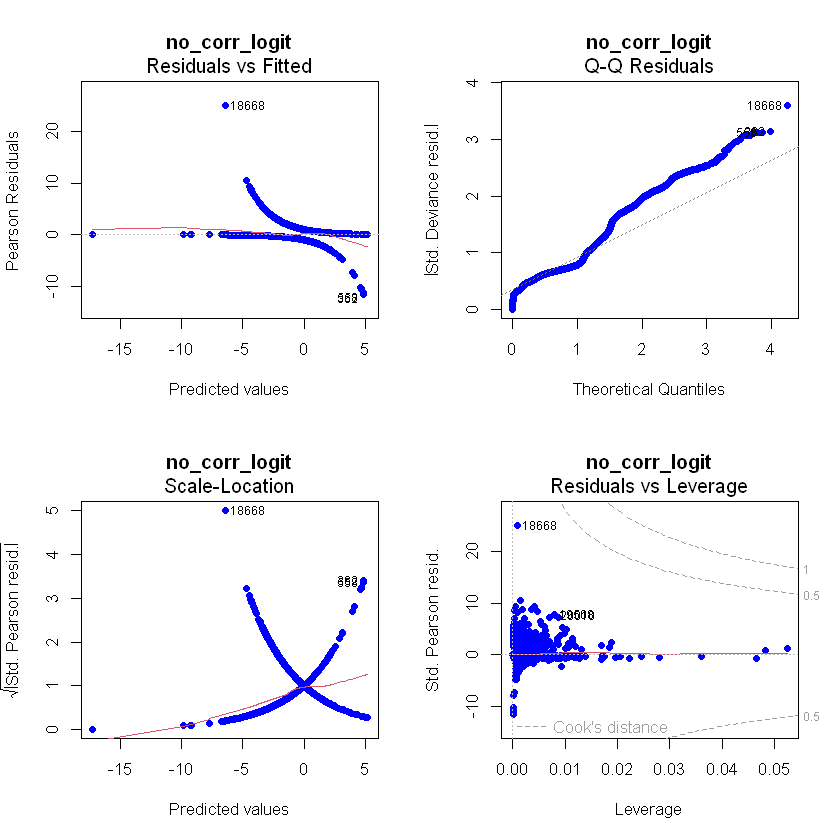

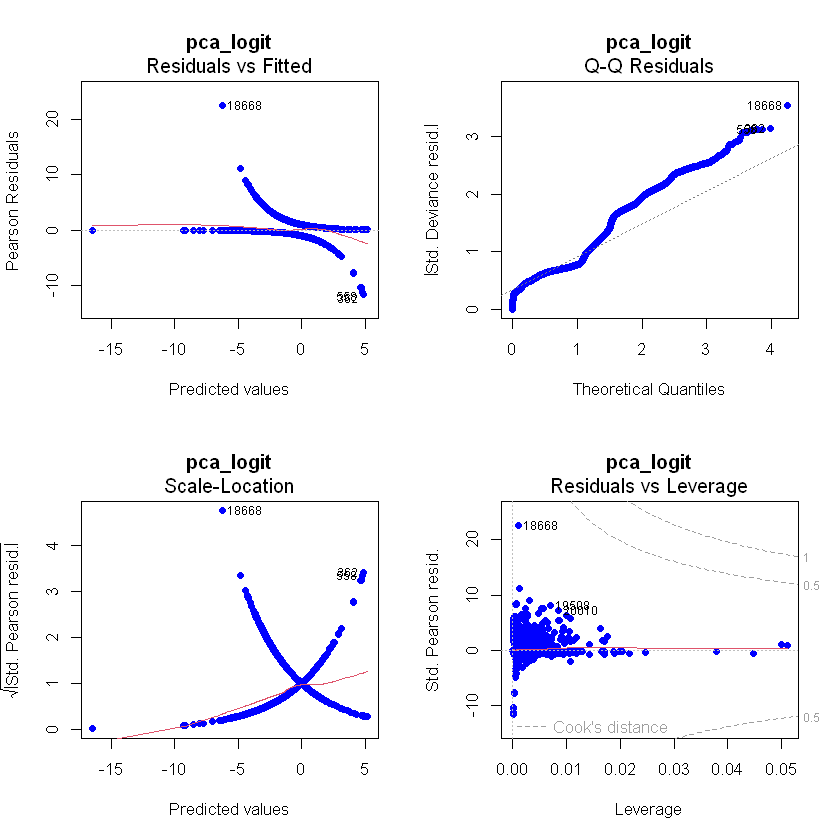

In [50]:
purrr::walk2(
  fits$fit,
  fits$wflow_id,
  ~ {
    modelo <- get_model(.x)

    par(mfrow = c(2, 2))
    plot(
      modelo,
      pch = 19,
      col = "blue",
      main = .y
    )
  }
)

[1] 919

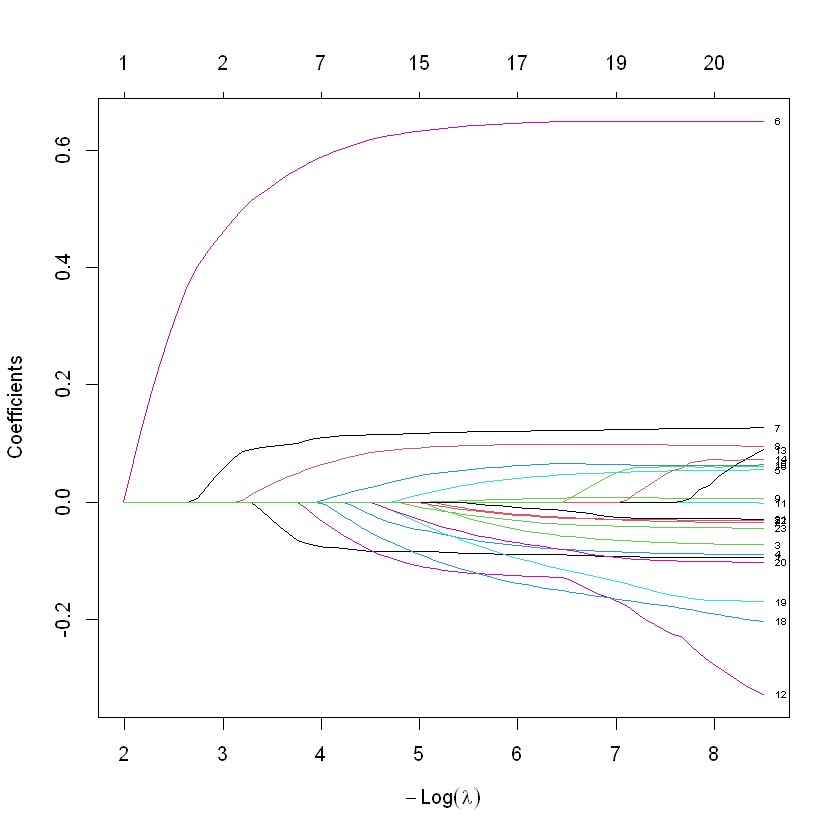

: 

In [ ]:
glmnet_fit <- fit_l1 %>%
  extract_fit_engine()
plot(glmnet_fit, xvar = "lambda", label = TRUE)

coef_l1 <- coef(glmnet_fit, s = glmnet_fit$lambda.min)

sum(coef_l1 != 0)

entendimento empírico do score: 

Com base no dataset:

Intervalo: 300 a 900 (limitado por definição institucional)
Média ≈ 600
Mediana = 600
Desvio padrão ≈ 172
Distribuição aproximadamente simétrica, sem caudas extremas
Variável ordinal-contínua, mas usada como contínua na prática

Forte interpretação causal esperada:

quanto maior o score, maior a chance de aprovação do empréstimo

# Priors para o Coeficiente do *CIBIL Score* em Regressão Bayesiana

## Contexto do Modelo

Considere o seguinte modelo de regressão logística bayesiana:

\[
\text{loan\_status}_i \sim \text{Bernoulli}(p_i)
\]

\[
\text{logit}(p_i) = \alpha + \beta \cdot \text{cibil\_score}_i
\]

onde `loan_status` é a variável binária indicadora de aprovação do empréstimo, e `cibil_score` representa o score de crédito do indivíduo, utilizado **em sua escala original**, aproximadamente no intervalo \([300, 900]\).

A escolha dos priors para o coeficiente \(\beta\) é central, pois essa variável possui **forte interpretação econômica e institucional**, diferentemente de covariáveis puramente observacionais.

---

## Plano de Priors Propostos

### 1. Prior Fraco (Weakly Informative)

\[
\beta \sim \mathcal{N}(0, 0.01)
\]

**Justificativa**

- Compatível com a escala original do `cibil_score`
- Permite efeitos positivos ou negativos
- Evita valores extremos no log-odds
- Funciona como *baseline* metodológico

**Interpretação**

Um aumento de 100 pontos no score implica, a priori, variações moderadas no log-odds, sem impor direção prévia ao efeito.

---

### 2. Prior Informativo Baseado em Conhecimento Econômico

\[
\beta \sim \mathcal{N}(0.005, 0.003)
\]

**Justificativa**

- Incorpora conhecimento prévio do mercado de crédito
- Reflete a expectativa de relação positiva entre score e aprovação
- Define magnitudes economicamente plausíveis

**Interpretação**

Este prior sugere que um aumento de 100 pontos no `cibil_score` eleva os *odds* de aprovação em aproximadamente 20% a 100%, intervalo condizente com práticas observadas em sistemas de avaliação de risco.

---

### 3. Prior Fortemente Informativo (Institucional) --> talvez

\[
\beta \sim \mathcal{N}(0.007, 0.001)
\]

**Justificativa**

- Representa crença institucional consolidada
- Assume efeito positivo bem definido
- Adequado para análises de sensibilidade

**Interpretação**

Este prior reduz significativamente a influência dos dados sobre o sinal do coeficiente, sendo útil para discutir o impacto de crenças fortes no posterior.
Esse prior vai mudar o posterior, mas não vai dominá-lo completamente.
Útil se quiser mostrar “o que acontece quando exageramos”

---

### 4. Prior Truncado (Monotonicidade Econômica)

\[
\beta \sim \mathcal{N}(0.005, 0.005), \quad \beta > 0
\]

**Justificativa**

- Impõe coerência econômica ao modelo
- Elimina efeitos negativos economicamente implausíveis
- Usado com frequência em modelos de risco de crédito

**Interpretação**

Assume-se explicitamente que aumentos no score **nunca** reduzem a probabilidade de aprovação, destacando o caráter normativo das escolhas bayesianas.


---

## Resumo das Escolhas de Priors

| Tipo de Prior | Grau de Informação | Direção Imposta | Objetivo |
|--------------|------------------|----------------|----------|
| Fraco | Baixo | Nenhuma | Baseline estatístico |
| Informativo | Médio | Positiva | Incorporar conhecimento econômico |
| Forte | Alto | Positiva | Simular crença institucional |
| Truncado | Médio–Alto | Positiva (obrigatória) | Impor coerência econômica |
| Hierárquico | Adaptativo | Nenhuma explícita | Flexibilidade metodológica |

---

## Observação Final

A utilização do `cibil_score` sem padronização permite que os priors sejam definidos diretamente na escala original da variável, tornando a interpretação dos coeficientes mais transparente e economicamente significativa, especialmente para variações de 50 ou 100 pontos no score.

escolha dos priors Laplace e Horseshoe permite investigar como diferentes mecanismos de regularização bayesiana afetam a inferência tanto em modelos univariados quanto multivariados. Enquanto o prior Laplace impõe shrinkage global e favorece parcimônia, o prior Horseshoe permite shrinkage adaptativo, preservando efeitos relevantes em cenários potencialmente esparsos.”

In [ ]:
Simulando um modelo de uma unica varável para buscar....

In [7]:
install.packages("Rtools")

Instalando pacote em 'C:/Users/T-GAMER/AppData/Local/R/win-library/4.5'
(como 'lib' não foi especificado)

Warning message:
"pacote 'Rtools' não está disponível for this version of R

Uma versão deste pacote para a sua versão do R pode estar disponível em outro lugar,
veja as ideias em
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages"


In [10]:
library(rstanarm)

This is rstanarm version 2.32.2

- See https://mc-stan.org/rstanarm/articles/priors for changes to default priors!

- Default priors may change, so it's safest to specify priors, even if equivalent to the defaults.

- For execution on a local, multicore CPU with excess RAM we recommend calling

  options(mc.cores = parallel::detectCores())


Anexando pacote: 'rstanarm'


Os seguintes objetos são mascarados por 'package:brms':

    dirichlet, exponential, get_y, lasso, ngrps




In [28]:
compare_logistic_models <- function(
  df,
  xvar,
  yvar,
  x0,
  grid_expand = 2,
  bayes_prior_sd = 2,
  cred_level = 0.9,
  glm_color = "#D55E00",
  bayes_color = "#0072B2",
  seed = 123
) {
  # Packages
  library(ggplot2)
  library(rstanarm)

  # -----------------------------
  # 1) Formula
  # -----------------------------
  form <- as.formula(paste(yvar, "~", xvar))

  # -----------------------------
  # 2) Frequentist model
  # -----------------------------
  fit_glm <- glm(form, data = df, family = binomial())

  # -----------------------------
  # 3) Bayesian model
  # -----------------------------
  fit_bayes <- stan_glm(
    form,
    data = df,
    family = binomial(),
    prior = normal(0, bayes_prior_sd),
    prior_intercept = normal(0, bayes_prior_sd),
    chains = 4,
    iter = 2000,
    seed = seed,
    refresh = 0
  )

  # -----------------------------
  # 4) X grid
  # -----------------------------
  x <- df[[xvar]]
  x_grid <- seq(
    min(x) - grid_expand,
    max(x) + grid_expand,
    length.out = 200
  )

  newdata <- data.frame(x_grid)
  names(newdata) <- xvar

  # -----------------------------
  # 5) Predictions
  # -----------------------------
  # Frequentist
  pred_glm <- predict(fit_glm, newdata = newdata, type = "response")

  # Bayesian posterior predictive mean
  post_epred <- posterior_epred(fit_bayes, newdata = newdata)

  alpha <- (1 - cred_level) / 2
  bayes_mean <- colMeans(post_epred)
  bayes_low  <- apply(post_epred, 2, quantile, alpha)
  bayes_high <- apply(post_epred, 2, quantile, 1 - alpha)

  # -----------------------------
  # 6) Single prediction at x0
  # -----------------------------
  x0_df <- data.frame(x0)
  names(x0_df) <- xvar

  glm_x0 <- predict(fit_glm, newdata = x0_df, type = "response")

  bayes_x0_draws <- posterior_epred(fit_bayes, newdata = x0_df)
  bayes_x0_mean  <- mean(bayes_x0_draws)
  bayes_x0_ci    <- quantile(bayes_x0_draws, c(alpha, 1 - alpha))

  # -----------------------------
  # 7) Prediction dataframe
  # -----------------------------
  pred_df <- data.frame(
    X = x_grid,
    glm = pred_glm,
    bayes = bayes_mean,
    low = bayes_low,
    high = bayes_high
  )

  # -----------------------------
  # 8) Plot
  # -----------------------------
  p <- ggplot(df, aes_string(xvar, yvar)) +
    geom_jitter(height = 0.03, alpha = 0.3) +

    geom_line(
      data = pred_df,
      aes(X, glm),
      color = glm_color,
      linewidth = 1
    ) +

    geom_line(
      data = pred_df,
      aes(X, bayes),
      color = bayes_color,
      linewidth = 1
    ) +

    geom_ribbon(
      data = pred_df,
      aes(X, ymin = low, ymax = high),
      inherit.aes = FALSE,
      fill = bayes_color,
      alpha = 0.25
    ) +

    geom_vline(xintercept = x0, linetype = "dashed") +

    geom_point(
      data = data.frame(X = x0, y = bayes_x0_mean),
      aes(X, y),
      size = 3,
      color = bayes_color
    ) +

    labs(
      y = "Probabilidade",
      title = "Regressão Logística: Frequentista vs Bayesiana",
      subtitle = paste(
        "X =", round(x0, 2),
        "| GLM =", round(glm_x0, 3),
        "| Bayes =", round(bayes_x0_mean, 3),
        "| CI =", paste(round(bayes_x0_ci, 3), collapse = "–")
      )
    ) +
    theme_minimal()

  # -----------------------------
  # 9) Return
  # -----------------------------
  list(
    plot = p,
    glm_pred_x0 = glm_x0,
    bayes_pred_x0_mean = bayes_x0_mean,
    bayes_pred_x0_ci = bayes_x0_ci,
    fit_glm = fit_glm,
    fit_bayes = fit_bayes
  )
}

In [29]:
set.seed(123)
n <- 400
X <- rnorm(n)
p <- plogis(1.2 * X)
y <- rbinom(n, 1, p)

df <- data.frame(X, y)

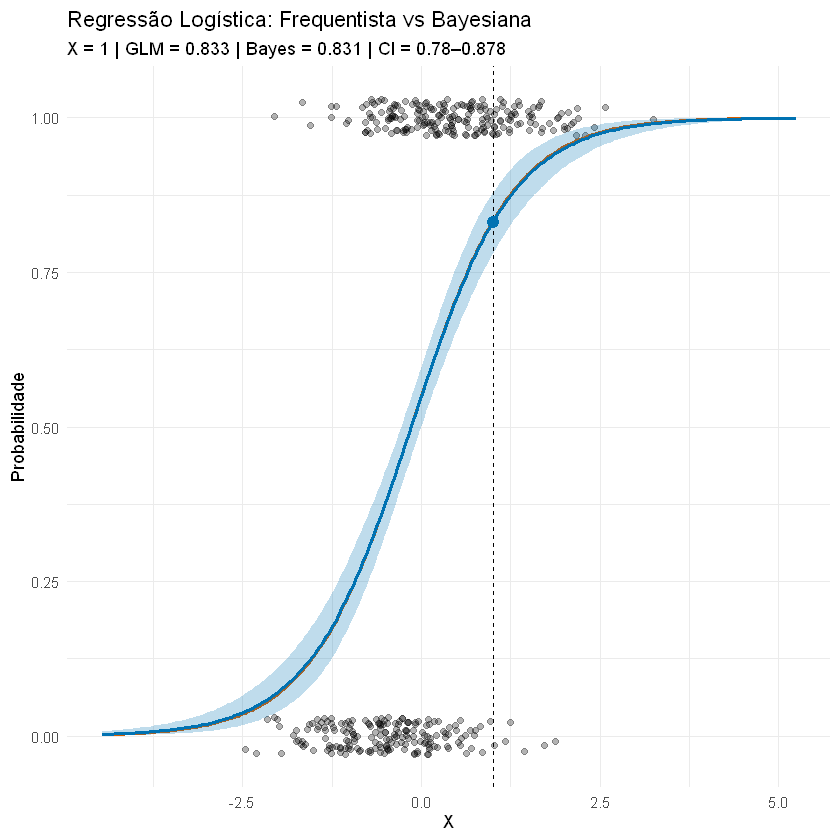

In [34]:
result <- compare_logistic_models(
  df = df,
  xvar = "X",
  yvar = "y",
  x0 = 1
)
result$plot

In [11]:
fit_glm <- glm(y ~ X, data = df, family = binomial())


fit_bayes <- stan_glm(
  y ~ X,
  data = df,
  family = binomial(link = "logit"),
  prior = normal(0, 2),
  prior_intercept = normal(0, 2),
  chains = 4,
  iter = 2000,
  seed = 123
)


SAMPLING FOR MODEL 'bernoulli' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.0033 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 33 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.121 seconds (Warm-up)
Chain 1:                0.119 seconds (Sampling)
Chain 1:                0.24 sec

In [12]:
X_grid <- seq(min(df$X) - 2, max(df$X) + 2, length.out = 200)
newdata <- data.frame(X = X_grid)

In [13]:
post_pred <- posterior_epred(
  fit_bayes,
  newdata = newdata
)

In [14]:
bayes_mean <- colMeans(post_pred)
bayes_low  <- apply(post_pred, 2, quantile, 0.05)
bayes_high <- apply(post_pred, 2, quantile, 0.95)

In [15]:
fit_glm <- glm(y ~ X, data = df, family = binomial())

pred_glm <- predict(
  fit_glm,
  newdata = newdata,
  type = "response"
)

In [17]:
pred_df <- data.frame(
  X = X_grid,
  pred_glm = pred_glm,
  bayes_mean = bayes_mean,
  bayes_low = bayes_low,
  bayes_high = bayes_high
)

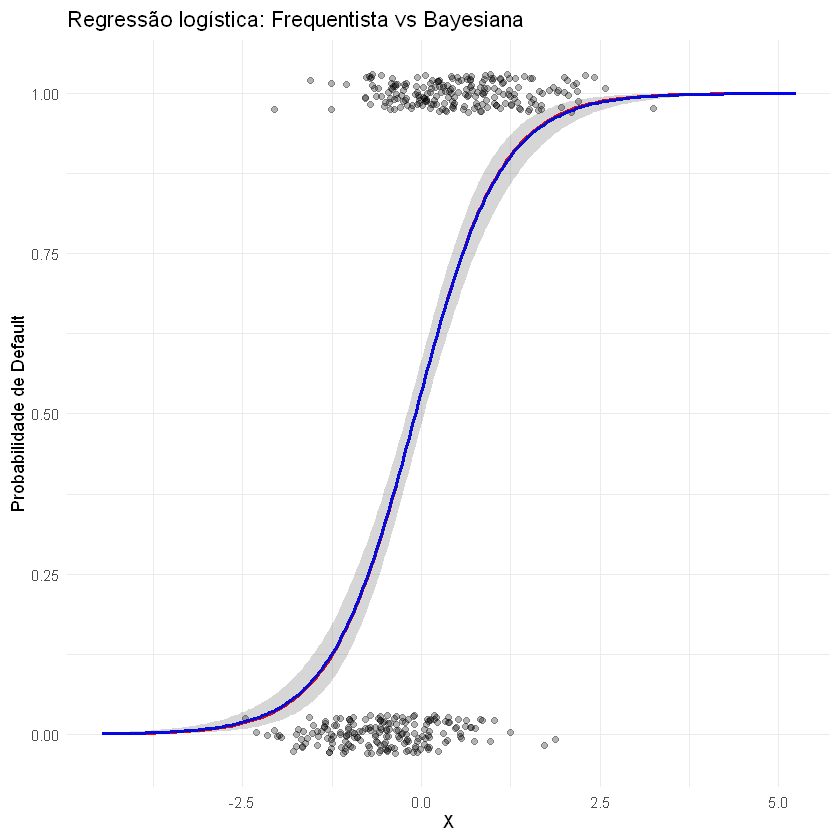

In [20]:
library(ggplot2)

ggplot(df, aes(X, y)) +
  geom_jitter(height = 0.03, alpha = 0.3) +

  geom_line(
    data = pred_df,
    aes(X, pred_glm),
    color = "red",
    linewidth = 1
  ) +

  geom_line(
    data = pred_df,
    aes(X, bayes_mean),
    color = "blue",
    linewidth = 1
  ) +

  geom_ribbon(
    data = pred_df,
    aes(x = X, ymin = bayes_low, ymax = bayes_high),
    inherit.aes = FALSE,
    alpha = 0.2
  ) +

  labs(
    y = "Probabilidade de Default",
    title = "Regressão logística: Frequentista vs Bayesiana"
  ) +
  theme_minimal()